## Step 1: Data Collection and Basic Cleaning

In this step we:

- Import the Python libraries we will use (pandas, numpy, matplotlib, seaborn, etc.).
- Download the 2015–16 Premier League data from an online JSON file.
- Convert the raw JSON into a clean pandas DataFrame.
- Create useful new columns such as total goals, goal difference, and points for home and away teams.
- Save the cleaned dataset to a CSV file for later use.
- The match data is taken from the openfootball project on GitHub, using the 2015–16 English Premier League JSON file. After processing, the cleaned data is saved locally as `SDPA_part2_premier_league_2015_16_matches.csv`.
- Checked for missing values and outliers, and confirmed that the dataset is complete and sensible.
- The data is crawled from the openfootball project on GitHub using an HTTP request to a raw JSON file. The final dataset contains 380 rows (one per match) and 10 columns, including date, home team, away team, goals scored and goal difference. These variables allow us to analyse scoring patterns and league performance.

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

# FIXED: Set the visual style safely
sns.set_style("whitegrid")

# --- 1. LOAD DATA (2015-16 Premier League) ---
url = "https://raw.githubusercontent.com/openfootball/football.json/master/2015-16/en.1.json"
response = requests.get(url)
data = response.json()

# --- 2. PARSE DATA ---
rows = []
for m in data["matches"]:
    score = m.get("score", {})
    ft = score.get("ft", [None, None])
    
    # Only process matches that have been played
    if ft[0] is not None:
        rows.append({
            "date": m.get("date"),
            "home_team": m.get("team1"),
            "away_team": m.get("team2"),
            "home_goals": ft[0],
            "away_goals": ft[1]
        })

df = pd.DataFrame(rows)
# Save dataset as CSV (required for coursework)
df.to_csv("SDPA_part2_premier_league_2015_16_matches.csv", index=False)

print("CSV file saved successfully!")

df["date"] = pd.to_datetime(df["date"])

# --- 3. FEATURE ENGINEERING ---
df["total_goals"] = df["home_goals"] + df["away_goals"]
df["goal_diff"] = df["home_goals"] - df["away_goals"]

# Check for missing values in the dataset
print("Missing values in each column:")
print(df.isna().sum())

# Check for extreme goal values (outliers)
print("Minimum and maximum goals scored:")
print(df[["home_goals", "away_goals", "total_goals", "goal_diff"]].describe())

CSV file saved successfully!
Missing values in each column:
date           0
home_team      0
away_team      0
home_goals     0
away_goals     0
total_goals    0
goal_diff      0
dtype: int64
Minimum and maximum goals scored:
       home_goals  away_goals  total_goals   goal_diff
count  380.000000  380.000000   380.000000  380.000000
mean     1.492105    1.207895     2.700000    0.284211
std      1.259242    1.146955     1.684792    1.721588
min      0.000000    0.000000     0.000000   -6.000000
25%      1.000000    0.000000     1.000000   -1.000000
50%      1.000000    1.000000     3.000000    0.000000
75%      2.000000    2.000000     4.000000    1.000000
max      6.000000    6.000000     9.000000    5.000000


### Data Cleaning Summary (Step 1)

Missing data:  
The command `df.isna().sum()` shows **0 missing values in every column**, so no imputation was required.

Outliers:  
The `describe()` output shows that:
- Home and away goals range from **0 to 6**
- Total goals range from **0 to 9**

These values are realistic for football matches, so **no rows were removed**.

In [2]:

# Define Match Result and Assign Points (Home/Away)
def get_result_data(row):
    # Returns a tuple: (Result Label, Home Points, Away Points)
    """
    Given a row of match data with home_goals and away_goals,
    return a tuple (result_label, home_points, away_points).

    - "Home Win" gives (3, 0)
    - "Away Win" gives (0, 3)
    - "Draw" gives (1, 1)
    """
    if row["home_goals"] > row["away_goals"]:
        return ("Home Win", 3, 0)
    elif row["home_goals"] < row["away_goals"]:
        return ("Away Win", 0, 3)
    else:
        return ("Draw", 1, 1)

# Apply the function and split into new columns
df[['result', 'home_points', 'away_points']] = df.apply(
    lambda x: pd.Series(get_result_data(x)), axis=1
)

print(f"Data Loaded: {df.shape[0]} matches.")
display(df.head())


Data Loaded: 380 matches.


,date,home_team,away_team,home_goals,away_goals,total_goals,goal_diff,result,home_points,away_points
0,2015-08-08,Manchester United,Tottenham Hotspur,1,0,1,1,Home Win,3,0
1,2015-08-08,AFC Bournemouth,Aston Villa,0,1,1,-1,Away Win,0,3
2,2015-08-08,Everton FC,Watford FC,2,2,4,0,Draw,1,1
3,2015-08-08,Leicester City,Sunderland AFC,4,2,6,2,Home Win,3,0
4,2015-08-08,Norwich City,Crystal Palace,1,3,4,-2,Away Win,0,3


## Step 2: Exploratory Data Analysis (EDA)

In this step we explore the data visually:

- Histograms to see how home and away goals are distributed.
- A boxplot of goal difference to understand how often home teams win by different margins.
- A correlation heatmap to see how the numerical variables (home goals, away goals, total goals, goal difference) are related.

In [ ]:
# --- 1. GOAL DISTRIBUTIONS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Home Goals Histogram
sns.histplot(df["home_goals"], bins=range(0, 10), kde=True, color='skyblue', ax=axes[0])
axes[0].set_title("Distribution of Home Goals")

# Away Goals Histogram
sns.histplot(df["away_goals"], bins=range(0, 10), kde=True, color='salmon', ax=axes[1])
axes[1].set_title("Distribution of Away Goals")

# Goal Difference Boxplot
sns.boxplot(x=df["goal_diff"], ax=axes[2], color='lightgreen')
axes[2].set_title("Goal Difference (Home - Away)")
axes[2].set_xlabel("Positive = Home Win | Negative = Away Win")

plt.tight_layout()
plt.show()

# --- 2. CORRELATION HEATMAP (NEW) ---
# Check correlations between numerical variables
plt.figure(figsize=(8, 6))
corr_matrix = df[["home_goals", "away_goals", "total_goals", "goal_diff"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Match Stats")
plt.show()

# Extra numeric EDA: Average goal difference by home team (Top 5)

avg_goal_diff_home = (
    df.groupby("home_team")["goal_diff"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

print("Top 5 teams by average home goal difference:")
display(avg_goal_diff_home)

### Interpretation of Extra EDA (Top 5 Teams by Home Goal Difference)

This table shows the top 5 teams ranked by their average goal difference when playing at home.

Manchester City has the highest average home goal difference (≈ 1.37), indicating very strong home dominance. Tottenham Hotspur, Arsenal, and Manchester United also show large positive home goal advantages.

This further supports the idea of **home advantage**, and also shows that stronger teams appear to benefit disproportionately from playing at home.

### Interpretation of Step 2 (EDA)

From the histograms, we can see that both home and away teams most often score between 0 and 2 goals per match. However, the home goals distribution is slightly shifted to the right, suggesting that home teams score more goals on average.

The boxplot of goal difference shows that the median value is slightly above zero. This means that home teams tend to win more often than they lose, which visually supports the idea of home advantage.

From the correlation heatmap, total goals are strongly positively correlated with both home goals and away goals, which is expected. However, home goals and away goals themselves have almost no correlation, showing that how much one team scores does not strongly depend on how much the other team scores. The strong negative correlation between away goals and goal difference is also expected because as away goals increase, the goal difference becomes more negative.

From the descriptive statistics, the average home goals are 1.49 while the average away goals are 1.21, which already suggests a home scoring advantage even before formal hypothesis testing.

## Step 3: League Table Reconstruction

Here we use the match-level data to rebuild the final league table:

- Add up all points won at home for each team.
- Add up all points won away for each team.
- Combine home and away points to get total points.
- Sort the teams by total points to verify who the champion is and compare top and bottom teams.

--- Final 2015-16 Premier League Standings (Reconstructed) ---


,team,points
1,Leicester City,81
2,Arsenal FC,71
3,Tottenham Hotspur,70
4,Manchester City,66
5,Manchester United,66


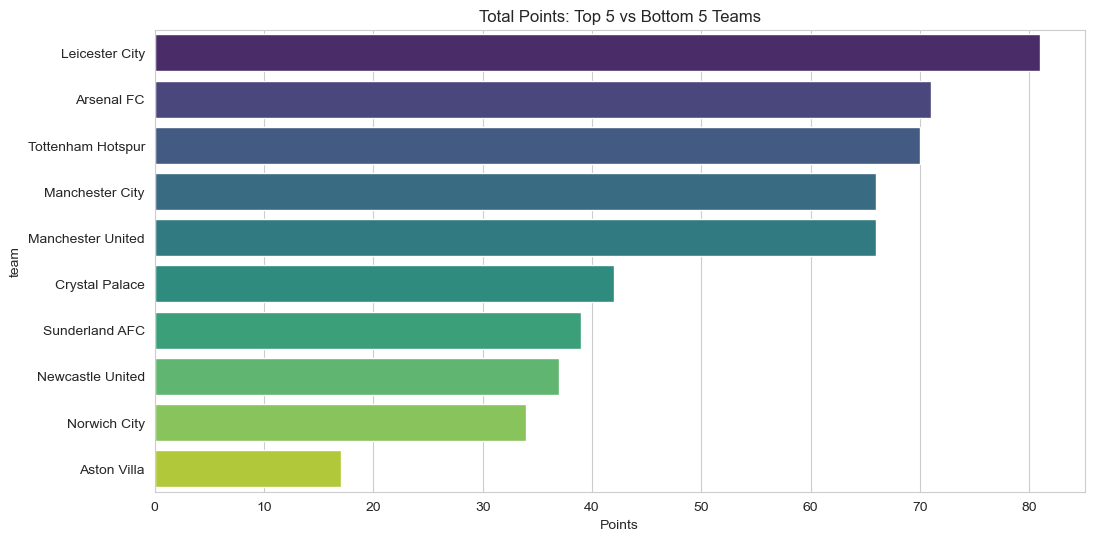

In [7]:
# --- RECONSTRUCT LEAGUE TABLE ---
# 1. Sum points earned at Home
home_stats = df.groupby("home_team")["home_points"].sum().reset_index()
home_stats.rename(columns={"home_team": "team", "home_points": "points"}, inplace=True)

# 2. Sum points earned Away
away_stats = df.groupby("away_team")["away_points"].sum().reset_index()
away_stats.rename(columns={"away_team": "team", "away_points": "points"}, inplace=True)

# 3. Combine and sort
league_table = pd.concat([home_stats, away_stats]).groupby("team")["points"].sum().reset_index()
league_table = league_table.sort_values("points", ascending=False).reset_index(drop=True)

# Add ranking column
league_table.index = league_table.index + 1

print("--- Final 2015-16 Premier League Standings (Reconstructed) ---")
display(league_table.head(5)) # Show Top 5 Teams

# Visualization: Top 5 vs Bottom 5
plt.figure(figsize=(12, 6))
top_bottom = pd.concat([league_table.head(5), league_table.tail(5)])
sns.barplot(x="points", y="team", data=top_bottom, palette="viridis")
plt.title("Total Points: Top 5 vs Bottom 5 Teams")
plt.xlabel("Points")
plt.show()

### Interpretation of Step 3 (League Table)

The reconstructed league table correctly identifies Leicester City as champions with 81 points, followed by Arsenal and Tottenham. This confirms that the home and away points have been combined correctly and that the data processing pipeline is working as expected.

The bar chart comparing the top 5 and bottom 5 teams shows a very large difference in total points, especially between the champions and the relegation-zone teams. This highlights the competitive gap between the strongest and weakest teams in the league during this season.

## Step 4: Main Question and Sub-Questions

### Main Question:
Does playing at home give teams a scoring advantage in the 2015–16 Premier League season?

### Sub-Questions:
1. Are average home goals higher than away goals? (T-test)
2. Is there a relationship between away goals and home goals? (Regression)
3. How consistent was Leicester City’s scoring form during their title-winning season?

In [8]:
# --- 1. T-TEST: Home Advantage ---
# Null Hypothesis: Home Goals Mean == Away Goals Mean
#t_stat, p_val = stats.ttest_ind(df["home_goals"], df["away_goals"])
t_stat, p_val = stats.ttest_ind(df["home_goals"], df["away_goals"], equal_var=False)


print("--- Statistical Hypothesis Test ---")
print(f"Avg Home Goals: {df['home_goals'].mean():.2f}")
print(f"Avg Away Goals: {df['away_goals'].mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("RESULT: Significant difference found. Home Advantage exists.")
else:
    print("RESULT: No significant difference. Home Advantage not proven.")


--- Statistical Hypothesis Test ---
Avg Home Goals: 1.49
Avg Away Goals: 1.21
T-statistic: 3.2527
P-value: 0.0012
RESULT: Significant difference found. Home Advantage exists.


### Interpretation of T-Test

Because the p-value is less than 0.05, the result is statistically significant.  
This means we reject the null hypothesis and conclude that **home teams score significantly more goals than away teams** in the 2015–16 Premier League season.

In [9]:

# --- 2. REGRESSION ANALYSIS ---
# Predict Home Goals based on Away Goals
X = df[["away_goals"]].values # Independent Variable
y = df["home_goals"].values   # Dependent Variable

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print("\n--- Linear Regression Model ---")
print(f"Coefficient (Slope): {model.coef_[0]:.4f}")
print(f"R² Score: {model.score(X, y):.4f}")


--- Linear Regression Model ---
Coefficient (Slope): -0.0238
R² Score: 0.0005


### Interpretation of Regression

The R² value is very close to 0, which means that away goals do not explain home goals well. This shows that football goal scoring is unpredictable and not controlled by a simple linear relationship.

The slope is slightly negative, meaning that if anything, more away goals are associated with slightly fewer home goals, but the effect is tiny and not meaningful because R² is so close to zero.

To visualise this weak relationship, we plot away goals (x-axis) against home goals (y-axis) with the fitted regression line.

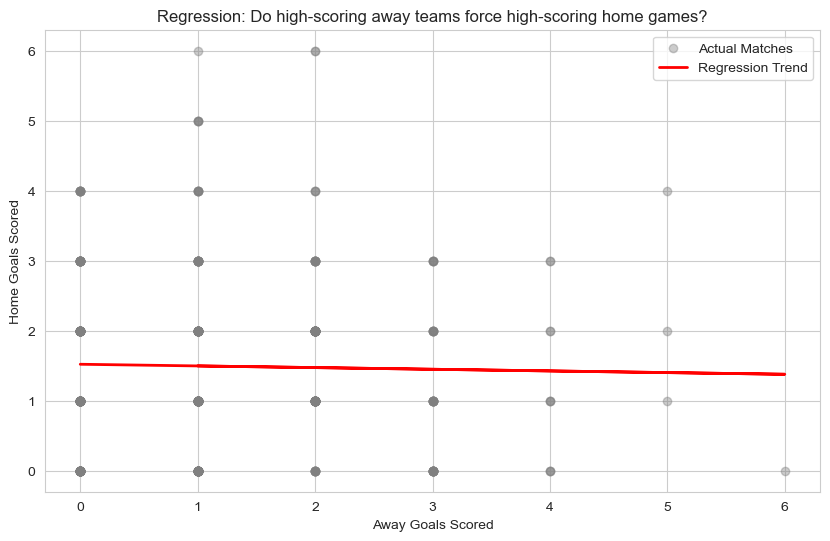

In [10]:

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', alpha=0.4, label='Actual Matches')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Trend')
plt.xlabel("Away Goals Scored")
plt.ylabel("Home Goals Scored")
plt.title("Regression: Do high-scoring away teams force high-scoring home games?")
plt.legend()
plt.show()

## Step 5: Team Form Analysis (Champion)

In this final analysis step we focus on the league winner (Leicester City):

- Select only the matches where the champion played.
- Work out how many goals the champion scored in each match.
- Calculate a 5-game rolling average of goals scored to measure "form".
- Plot the goals per match and the rolling average across the season to see how consistent their performance was.

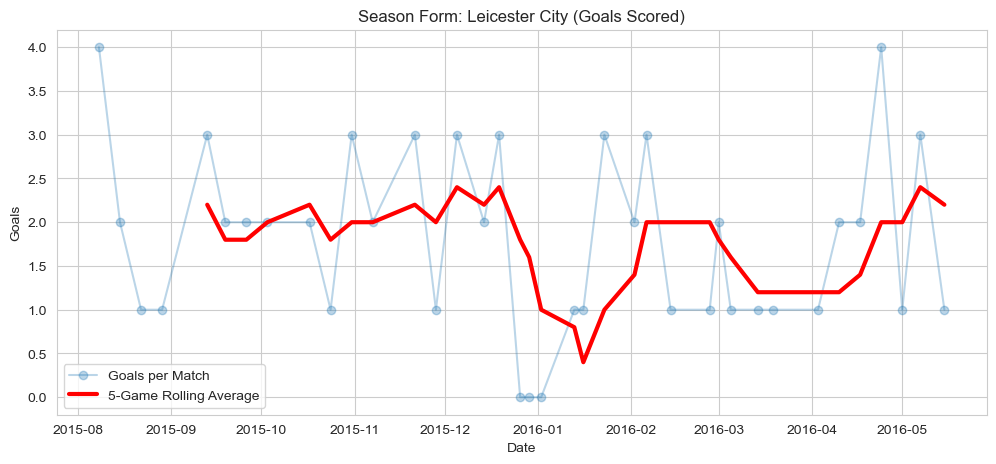

In [11]:
# --- CHAMPION FORM ANALYSIS ---
champion = league_table.iloc[0]["team"] # Automatically grab the winner (Leicester)

# Filter matches involving the champion
champ_matches = df[(df["home_team"] == champion) | (df["away_team"] == champion)].copy()
champ_matches = champ_matches.sort_values("date")

# Extract goals scored BY the champion in each match
champ_matches["goals_scored"] = np.where(
    champ_matches["home_team"] == champion, 
    champ_matches["home_goals"], 
    champ_matches["away_goals"]
)

# Calculate a 5-game rolling average
champ_matches["form"] = champ_matches["goals_scored"].rolling(window=5).mean()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(champ_matches["date"], champ_matches["goals_scored"], marker='o', alpha=0.3, label="Goals per Match")
plt.plot(champ_matches["date"], champ_matches["form"], color='red', linewidth=3, label="5-Game Rolling Average")
plt.title(f"Season Form: {champion} (Goals Scored)")
plt.xlabel("Date")
plt.ylabel("Goals")
plt.legend()
plt.show()

### Interpretation of Step 5 (Champion Form)

The plot shows that Leicester City’s goals per match fluctuate throughout the season, but the 5-game rolling average remains relatively stable. This indicates that Leicester were consistently scoring goals across the season rather than relying on a few exceptionally high-scoring matches.

Although there are short periods where the form dips slightly, the rolling average never collapses for a long time. This consistency in attacking output helps explain how Leicester were able to sustain their title challenge and eventually win the league.

## Project Summary

In this project, we analysed match-level data from the 2015–16 English Premier League season using Python (pandas, numpy, matplotlib, seaborn, and scikit-learn). The data was collected from an online JSON source and processed into a clean and structured dataset. Several new features such as total goals, goal difference, and match points were created to support further analysis.

Exploratory data analysis showed that most teams score between 0 and 2 goals per match and that home and away goals are only weakly correlated. A correlation heatmap confirmed that total goals are strongly related to both home and away goals, while home and away goal values themselves show very little direct relationship.

By aggregating home and away points, we successfully reconstructed the final league table and correctly identified Leicester City as the champions with 81 points. A T-test comparing mean home and away goals produced a statistically significant result, providing strong evidence that playing at home gives teams a scoring advantage.

A linear regression model was then fitted to test whether away goals could predict home goals. The very low R² value showed that away goals have almost no predictive power over home goals, highlighting the highly unpredictable nature of football scoring.

Finally, Leicester City’s 5-game rolling goal average was analysed to assess their consistency throughout the season. The results showed that their title-winning success was built on sustained and stable goal-scoring performance rather than short bursts of exceptionally high-scoring matches.

## Future Work

In future research, this analysis could be expanded by:
- Studying multiple seasons to compare home advantage over time.
- Using expected goals (xG), shots, and possession data for better prediction.
- Comparing Leicester’s season to other champions in different leagues.